# Invoice DocAI v2 — Full Pipeline Runner

**Open in Colab with GPU runtime (T4), then Run All.**

This notebook runs the complete pipeline:
1. Setup & mount Drive
2. Rebuild manifests (fix paths for Colab)
3. OCR Baseline (EasyOCR on 347 val docs)
4. Donut Pretrained Inference
5. Donut Fine-tuning on SROIE (5 epochs by default)
6. Robustness Evaluation (messenger-grade corruption)
7. Summary & Visualizations

**Typical time on Colab T4:**
- Steps 0-3 (setup + OCR + pretrained): ~20-45 min
- Step 4 (fine-tuning, 5 epochs): ~1.5-3 hours
- Full pipeline end-to-end: usually ~2-4 hours

**Памятка по режимам запуска:**
- `quick` (по умолчанию): быстрый прогон на подвыборке, результаты сохраняются в файлы с суффиксом `_quick`
- `full`: полный прогон на всём датасете (дольше, но точнее)
- Чтобы запустить full, перед Run All выполните: `%env RUN_PROFILE=full`
- Чтобы вернуться в quick: `%env RUN_PROFILE=quick`

---
## 0. Setup: Mount Drive, Find Project, Install Deps

In [31]:
# ============================================================================
# SETUP: Mount Drive, download dataset, set up project structure
# ============================================================================
import subprocess, sys, shutil
from pathlib import Path

# Mount Google Drive (required for persistent outputs)
DRIVE_ROOT = Path('/content/drive/MyDrive')
DRIVE_OUTPUT_DIR = None
DRIVE_MOUNTED = False

try:
    from google.colab import drive
    if not DRIVE_ROOT.exists():
        drive.mount('/content/drive', force_remount=False)
    DRIVE_MOUNTED = DRIVE_ROOT.exists()
except Exception as e:
    DRIVE_MOUNTED = DRIVE_ROOT.exists()
    print(f'Drive mount failed or not in Colab: {e}')

if DRIVE_MOUNTED:
    DRIVE_OUTPUT_DIR = DRIVE_ROOT / 'invoice_docai' / 'v2' / 'outputs'
    DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print(f'DRIVE_OUTPUT_DIR = {DRIVE_OUTPUT_DIR}')
else:
    print('WARNING: Google Drive is not mounted. Outputs on /content are temporary!')

# --- Project root in Colab local filesystem (fast SSD) ---
PROJECT_ROOT = Path('/content/invoice_docai')
PROJECT_ROOT.mkdir(exist_ok=True)

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'Drive mounted: {DRIVE_MOUNTED}')

Mounted at /content/drive
DRIVE_OUTPUT_DIR = /content/drive/MyDrive/invoice_docai/v2/outputs
PROJECT_ROOT = /content/invoice_docai
Drive mounted: True


In [4]:
# ============================================================================
# Download & unpack SROIE dataset from Google Drive
# ============================================================================
SROIE_DIR = PROJECT_ROOT / 'data' / 'sroie' / 'raw' / 'SROIE2019'

if (SROIE_DIR / 'train' / 'img').exists() and (SROIE_DIR / 'test' / 'img').exists():
    print('Dataset already unpacked. Skipping download.')
else:
    # Download zip from Google Drive using gdown
    ZIP_FILE_ID = '1G3JEGC1sGGN4VR4obobKqU7psrKhsVGy'
    ZIP_PATH = Path('/content/sroie_dataset.zip')

    if not ZIP_PATH.exists():
        print('Downloading sroie_dataset.zip from Google Drive...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=True)
        import gdown
        gdown.download(id=ZIP_FILE_ID, output=str(ZIP_PATH), quiet=False)
        print(f'Downloaded: {ZIP_PATH.stat().st_size / 1024 / 1024:.0f} MB')
    else:
        print(f'Zip already downloaded: {ZIP_PATH.stat().st_size / 1024 / 1024:.0f} MB')

    # Unpack
    RAW_DIR = PROJECT_ROOT / 'data' / 'sroie' / 'raw'
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    print('Unpacking...')
    subprocess.run(['unzip', '-qo', str(ZIP_PATH), '-d', str(RAW_DIR)], check=True)
    print('Done unpacking.')

# Verify
train_imgs = list((SROIE_DIR / 'train' / 'img').glob('*.jpg'))
val_imgs = list((SROIE_DIR / 'test' / 'img').glob('*.jpg'))
train_ents = list((SROIE_DIR / 'train' / 'entities').glob('*.txt'))
val_ents = list((SROIE_DIR / 'test' / 'entities').glob('*.txt'))
print(f'Train: {len(train_imgs)} images, {len(train_ents)} labels')
print(f'Val:   {len(val_imgs)} images, {len(val_ents)} labels')
assert len(train_imgs) >= 600, f'Expected 626 train images, got {len(train_imgs)}'
assert len(val_imgs) >= 300, f'Expected 347 val images, got {len(val_imgs)}'
print('=== Dataset OK ===')

Downloading...
From (original): https://drive.google.com/uc?id=1G3JEGC1sGGN4VR4obobKqU7psrKhsVGy
From (redirected): https://drive.google.com/uc?id=1G3JEGC1sGGN4VR4obobKqU7psrKhsVGy&confirm=t&uuid=6e971c08-ded7-4423-8d40-20b0c1afbc02
To: /content/sroie_dataset.zip
100%|██████████| 455M/455M [00:03<00:00, 122MB/s]  


Downloaded: 434 MB
Unpacking...
Done unpacking.
Train: 626 images, 626 labels
Val:   347 images, 347 labels
=== Dataset OK ===


In [6]:
# ============================================================================
# Copy v2/src from Google Drive to Colab local filesystem
# (with fallback: write docai_utils.py inline if Drive is unavailable)
# ============================================================================

V2_SRC = PROJECT_ROOT / 'v2' / 'src'
V2_SRC.mkdir(parents=True, exist_ok=True)
dst_file = V2_SRC / 'docai_utils.py'

# --- Try to find v2 on Google Drive first ---
V2_DRIVE = None
if DRIVE_MOUNTED:
    drive_candidates = [
        Path('/content/drive/MyDrive/v2'),
        Path('/content/drive/MyDrive/invoice_docai/v2'),
        Path('/content/drive/MyDrive/ORC/invoice_docai/v2'),
    ]
    for p in drive_candidates:
        if (p / 'src' / 'docai_utils.py').exists():
            V2_DRIVE = p
            break

    if V2_DRIVE is None:
        print('Searching for v2/src/docai_utils.py on Drive...')
        for p in Path('/content/drive/MyDrive').rglob('docai_utils.py'):
            if 'v2' in str(p):
                V2_DRIVE = p.parent.parent
                break

if V2_DRIVE is not None:
    src_file = V2_DRIVE / 'src' / 'docai_utils.py'
    shutil.copy2(src_file, dst_file)
    print(f'Copied docai_utils.py from Drive ({dst_file.stat().st_size:,} bytes)')
else:
    # --- Fallback: write docai_utils.py inline ---
    print('Drive not available — writing docai_utils.py inline...')
    _DOCAI_UTILS_CODE = r'''"""
Invoice DocAI — shared utilities (v2, improved).

Changes vs v1:
- normalize_date: supports DD/MM/YY, month names ("15 Jan 21"), return_raw option
- normalize_total: return_raw option, negative value validation
- build_manifest: rel_to for portable paths, gt_date_raw / gt_total_raw columns
- compute_field_metrics: ignore_empty_gt, support count
- evaluate: ignore_empty_gt (default True for fair evaluation)
- NEW: extract_total_from_lines — keyword-priority + range filter (fixes phone-number bug)
- NEW: extract_vendor_from_lines — skip-pattern filtering
- NEW: extract_date_from_lines, extract_fields_from_lines
- NEW: messenger_corrupt for robustness evaluation
"""

import json
import random
import re
from decimal import Decimal, InvalidOperation
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# Regex patterns
# ---------------------------------------------------------------------------

DATE_PATTERNS = [
    re.compile(r"\b(\d{2})[./-](\d{2})[./-](\d{4})\b"),
    re.compile(r"\b(\d{4})[./-](\d{2})[./-](\d{2})\b"),
    re.compile(r"\b(\d{2})[./-](\d{2})[./-](\d{2})\b"),
]

MONTH_NAMES = {
    "jan": 1, "january": 1, "feb": 2, "february": 2,
    "mar": 3, "march": 3, "apr": 4, "april": 4, "may": 5,
    "jun": 6, "june": 6, "jul": 7, "july": 7,
    "aug": 8, "august": 8, "sep": 9, "september": 9,
    "oct": 10, "october": 10, "nov": 11, "november": 11,
    "dec": 12, "december": 12,
}
MONTH_NAME_PATTERN = re.compile(
    r"\b(\d{1,2})\s+([a-z]{3,9})\s+(\d{2,4})\b", re.IGNORECASE
)

MONEY_PATTERN = re.compile(r"[-+]?\d+[\d\s.,]*\d")

DATE_REGEX = re.compile(
    r"\b(\d{2}[./-]\d{2}[./-]\d{4}|\d{4}[./-]\d{2}[./-]\d{2})\b"
)

_VENDOR_SKIP_PATTERNS = [
    re.compile(r"\d{2}[./-]\d{2}[./-]\d{4}", re.IGNORECASE),
    re.compile(r"\b(tel|fax|phone|email|www|http)\b", re.IGNORECASE),
    re.compile(r"\b(no\.\s*\d|no:\s*\d)", re.IGNORECASE),
    re.compile(r"\b(gst\s*id|tax\s*id|reg\s*no)\b", re.IGNORECASE),
    re.compile(r"\b(cashier|counter|receipt|invoice\s*no)\b", re.IGNORECASE),
]

_TOTAL_SKIP_KEYWORDS = [
    "subtotal", "sub total", "sub-total",
    "total qty", "total item", "total quantity",
    "total excluded", "total tax",
]


# ---------------------------------------------------------------------------
# Normalization helpers
# ---------------------------------------------------------------------------

def normalize_total(value: Any, return_raw: bool = False) -> str:
    if value is None:
        return ("", "") if return_raw else ""
    text = str(value).strip()
    if not text:
        return ("", "") if return_raw else ""
    raw_text = text
    text = text.replace(" ", "").replace("$", "").replace("\u20ac", "").replace("RM", "")
    text = text.replace(",", ".")
    match = MONEY_PATTERN.search(text)
    if not match:
        return ("", raw_text) if return_raw else ""
    candidate = match.group(0)
    if candidate.count(".") > 1:
        parts = candidate.split(".")
        candidate = "".join(parts[:-1]) + "." + parts[-1]
    try:
        value_dec = Decimal(candidate)
        if value_dec < 0:
            return ("", raw_text) if return_raw else ""
        result = f"{value_dec:.2f}"
        return (result, raw_text) if return_raw else result
    except InvalidOperation:
        return ("", raw_text) if return_raw else ""


def normalize_date(value: Any, return_raw: bool = False) -> str:
    if value is None:
        return ("", "") if return_raw else ""
    text = str(value).strip()
    if not text:
        return ("", "") if return_raw else ""
    raw_text = text
    month_match = MONTH_NAME_PATTERN.search(text)
    if month_match:
        day_str, month_str, year_str = month_match.groups()
        month_lower = month_str.lower()
        if month_lower in MONTH_NAMES:
            try:
                day = int(day_str)
                month = MONTH_NAMES[month_lower]
                year = int(year_str)
                if year < 100:
                    year = 2000 + year if year <= 50 else 1900 + year
                if 1 <= month <= 12 and 1 <= day <= 31 and 1900 <= year <= 2100:
                    result = f"{year:04d}-{month:02d}-{day:02d}"
                    return (result, raw_text) if return_raw else result
            except ValueError:
                pass
    for pattern in DATE_PATTERNS:
        match = pattern.search(text)
        if not match:
            continue
        a, b, c = match.groups()
        if len(a) == 4:
            year, month, day = a, b, c
        elif len(c) == 4:
            day, month, year = a, b, c
        elif len(c) == 2:
            day, month, year = a, b, c
            year_int = int(year)
            year = str(2000 + year_int if year_int <= 50 else 1900 + year_int)
        else:
            continue
        try:
            year_int = int(year)
            month_int = int(month)
            day_int = int(day)
            if not (1 <= month_int <= 12 and 1 <= day_int <= 31 and 1900 <= year_int <= 2100):
                continue
            result = f"{year_int:04d}-{month_int:02d}-{day_int:02d}"
            return (result, raw_text) if return_raw else result
        except ValueError:
            continue
    return ("", raw_text) if return_raw else ""


def normalize_vendor(value: Any) -> str:
    if value is None:
        return ""
    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


# ---------------------------------------------------------------------------
# Field extraction from OCR lines (v2)
# ---------------------------------------------------------------------------

def extract_total_from_lines(lines: List[str]) -> str:
    cleaned = [ln.strip() for ln in lines if ln and ln.strip()]
    if not cleaned:
        return ""
    keyword_candidates: List[Tuple[float, str]] = []
    for ln in cleaned:
        ln_lower = ln.lower()
        if any(skip in ln_lower for skip in _TOTAL_SKIP_KEYWORDS):
            continue
        if not re.search(r"\btotal\b", ln_lower):
            continue
        amount = normalize_total(ln)
        if amount:
            val = float(amount)
            if 0.01 <= val <= 50_000:
                keyword_candidates.append((val, amount))
    if keyword_candidates:
        return keyword_candidates[-1][1]
    for ln in cleaned:
        ln_lower = ln.lower()
        if re.search(r"\b(amount|rounding|round\s*adj|change)\b", ln_lower):
            amount = normalize_total(ln)
            if amount:
                val = float(amount)
                if 0.01 <= val <= 50_000:
                    return amount
    bottom_half = cleaned[len(cleaned) // 2:]
    money_candidates: List[Tuple[float, str]] = []
    for ln in bottom_half:
        matches = re.findall(r"\b(\d{1,6}\.\d{2})\b", ln)
        for m in matches:
            val = float(m)
            if 0.01 <= val <= 50_000:
                money_candidates.append((val, normalize_total(m)))
    if money_candidates:
        money_candidates.sort(key=lambda x: x[0], reverse=True)
        return money_candidates[0][1]
    for ln in cleaned:
        matches = re.findall(r"\b(\d{1,6}\.\d{2})\b", ln)
        for m in matches:
            val = float(m)
            if 0.01 <= val <= 50_000:
                return normalize_total(m)
    return ""


def extract_vendor_from_lines(lines: List[str]) -> str:
    cleaned = [ln.strip() for ln in lines if ln and ln.strip()]
    if not cleaned:
        return ""
    candidates: List[Tuple[int, str, int]] = []
    for i, ln in enumerate(cleaned[:6]):
        letters = sum(ch.isalpha() for ch in ln)
        digits = sum(ch.isdigit() for ch in ln)
        if letters < 3:
            continue
        if digits > letters:
            continue
        if any(pat.search(ln) for pat in _VENDOR_SKIP_PATTERNS):
            continue
        candidates.append((i, ln, letters))
    if candidates:
        candidates.sort(key=lambda x: x[2], reverse=True)
        return candidates[0][1]
    for ln in cleaned[:5]:
        if sum(ch.isalpha() for ch in ln) >= 3:
            return ln
    return ""


def extract_date_from_lines(lines: List[str]) -> str:
    for ln in lines:
        if not ln:
            continue
        m = DATE_REGEX.search(ln.strip())
        if m:
            d = normalize_date(m.group(1))
            if d:
                return d
    return ""


def extract_fields_from_lines(lines: List[str]) -> Dict[str, str]:
    return {
        "pred_vendor": extract_vendor_from_lines(lines),
        "pred_date": extract_date_from_lines(lines),
        "pred_total": extract_total_from_lines(lines),
    }


# ---------------------------------------------------------------------------
# Messenger-grade image corruption
# ---------------------------------------------------------------------------

def messenger_corrupt(
    img_bgr: np.ndarray,
    jpeg_quality: int = 20,
    blur_kernel: int = 5,
    perspective: float = 0.08,
    downscale: float = 0.55,
) -> np.ndarray:
    import cv2
    h, w = img_bgr.shape[:2]
    src = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]])
    dx = max(1, int(w * perspective))
    dy = max(1, int(h * perspective))
    dst = np.float32([
        [random.randint(0, dx), random.randint(0, dy)],
        [w - 1 - random.randint(0, dx), random.randint(0, dy)],
        [w - 1 - random.randint(0, dx), h - 1 - random.randint(0, dy)],
        [random.randint(0, dx), h - 1 - random.randint(0, dy)],
    ])
    M = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(img_bgr, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    k = max(3, blur_kernel if blur_kernel % 2 == 1 else blur_kernel + 1)
    blurred = cv2.GaussianBlur(warped, (k, k), 0)
    new_w, new_h = max(1, int(w * downscale)), max(1, int(h * downscale))
    small = cv2.resize(blurred, (new_w, new_h), interpolation=cv2.INTER_AREA)
    restored = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
    ok, enc = cv2.imencode(".jpg", restored, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
    if not ok:
        return restored
    return cv2.imdecode(enc, cv2.IMREAD_COLOR)


# ---------------------------------------------------------------------------
# SROIE label parsing & manifest building
# ---------------------------------------------------------------------------

def parse_sroie_label(label_path: Path) -> Dict[str, str]:
    content = label_path.read_text(encoding="utf-8", errors="ignore").strip()
    result = {"vendor": "", "date": "", "total": ""}
    if not content:
        return result
    try:
        payload = json.loads(content)
        if isinstance(payload, dict):
            result["vendor"] = str(payload.get("company") or payload.get("vendor") or "")
            result["date"] = str(payload.get("date") or "")
            result["total"] = str(payload.get("total") or payload.get("amount") or "")
            return result
    except json.JSONDecodeError:
        pass
    lines = [line.strip() for line in content.splitlines() if line.strip()]
    lowered = [line.lower() for line in lines]
    for line in lines:
        if re.search(r"\btotal\b", line, flags=re.IGNORECASE):
            amount = normalize_total(line)
            if amount:
                result["total"] = amount
    if not result["total"]:
        amounts = [normalize_total(line) for line in lines]
        amounts = [a for a in amounts if a]
        if amounts:
            result["total"] = max(amounts, key=lambda x: Decimal(x))
    for line in lines:
        d = normalize_date(line)
        if d:
            result["date"] = d
            break
    if lines:
        result["vendor"] = lines[0]
    for idx, line in enumerate(lowered):
        if "company" in line or "vendor" in line:
            value = lines[idx].split(":", 1)[-1].strip()
            result["vendor"] = value or result["vendor"]
            break
    return result


def build_manifest(
    images_dir: Path,
    labels_dir: Path,
    rel_to: Optional[Path] = None,
) -> pd.DataFrame:
    image_paths = sorted(
        list(images_dir.glob("*.jpg"))
        + list(images_dir.glob("*.png"))
        + list(images_dir.glob("*.jpeg"))
    )
    records: List[Dict[str, str]] = []
    for image_path in image_paths:
        stem = image_path.stem
        label_path = labels_dir / f"{stem}.txt"
        gt = parse_sroie_label(label_path) if label_path.exists() else {
            "vendor": "", "date": "", "total": ""
        }
        date_normalized, date_raw = normalize_date(gt["date"], return_raw=True)
        total_normalized, total_raw = normalize_total(gt["total"], return_raw=True)
        if rel_to:
            try:
                img_path_str = image_path.relative_to(rel_to).as_posix()
                lbl_path_str = (
                    label_path.relative_to(rel_to).as_posix()
                    if label_path.exists() else ""
                )
            except ValueError:
                img_path_str = str(image_path)
                lbl_path_str = str(label_path) if label_path.exists() else ""
        else:
            img_path_str = str(image_path)
            lbl_path_str = str(label_path) if label_path.exists() else ""
        records.append({
            "id": stem,
            "image_path": img_path_str,
            "label_path": lbl_path_str,
            "gt_vendor": gt["vendor"],
            "gt_date": date_normalized,
            "gt_total": total_normalized,
            "gt_date_raw": date_raw,
            "gt_total_raw": total_raw,
        })
    return pd.DataFrame(records)


# ---------------------------------------------------------------------------
# Evaluation metrics
# ---------------------------------------------------------------------------

def compute_field_metrics(
    y_true: List[str],
    y_pred: List[str],
    ignore_empty_gt: bool = False,
) -> Dict[str, float]:
    tp = fp = fn = 0
    support = 0
    for t, p in zip(y_true, y_pred):
        t_strip = str(t).strip()
        p_strip = str(p).strip()
        t_ok = bool(t_strip)
        p_ok = bool(p_strip)
        if ignore_empty_gt and not t_ok:
            continue
        support += 1
        if p_ok and t_ok and p_strip == t_strip:
            tp += 1
        elif p_ok and (not t_ok or p_strip != t_strip):
            fp += 1
        elif t_ok and not p_ok:
            fn += 1
        elif t_ok and p_ok and p_strip != t_strip:
            fp += 1
            fn += 1
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "precision": precision, "recall": recall, "f1": f1,
        "tp": tp, "fp": fp, "fn": fn, "support": support,
    }


def evaluate(
    ground_truth_df: pd.DataFrame,
    predictions_df: pd.DataFrame,
    ignore_empty_gt: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    merged = ground_truth_df.merge(predictions_df, on="id", how="inner")
    for col in ["gt_vendor", "pred_vendor"]:
        merged[col] = merged[col].fillna("").map(normalize_vendor)
    for col in ["gt_date", "pred_date"]:
        merged[col] = merged[col].fillna("").map(normalize_date)
    for col in ["gt_total", "pred_total"]:
        merged[col] = merged[col].fillna("").map(normalize_total)
    metrics_rows = []
    total_tp = total_fp = total_fn = 0
    total_support = 0
    for field in ["vendor", "date", "total"]:
        field_metrics = compute_field_metrics(
            merged[f"gt_{field}"].tolist(),
            merged[f"pred_{field}"].tolist(),
            ignore_empty_gt=ignore_empty_gt,
        )
        if ignore_empty_gt:
            mask = merged[f"gt_{field}"].str.strip() != ""
            subset = merged[mask]
            exact = (
                (subset[f"gt_{field}"] == subset[f"pred_{field}"]).mean()
                if len(subset) else 0.0
            )
        else:
            exact = (
                (merged[f"gt_{field}"] == merged[f"pred_{field}"]).mean()
                if len(merged) else 0.0
            )
        field_metrics["field"] = field
        field_metrics["exact_match"] = exact
        metrics_rows.append(field_metrics)
        total_tp += field_metrics["tp"]
        total_fp += field_metrics["fp"]
        total_fn += field_metrics["fn"]
        total_support += field_metrics["support"]
    micro_p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0.0
    micro_r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0.0
    micro_f1 = (
        2 * micro_p * micro_r / (micro_p + micro_r)
        if (micro_p + micro_r) else 0.0
    )
    metrics_rows.append({
        "field": "micro",
        "precision": micro_p, "recall": micro_r, "f1": micro_f1,
        "exact_match": np.nan,
        "tp": total_tp, "fp": total_fp, "fn": total_fn,
        "support": total_support,
    })
    metrics_df = pd.DataFrame(metrics_rows)
    errors = merged[
        (merged["gt_vendor"] != merged["pred_vendor"])
        | (merged["gt_date"] != merged["pred_date"])
        | (merged["gt_total"] != merged["pred_total"])
    ].copy()
    errors["num_wrong_fields"] = (
        (errors["gt_vendor"] != errors["pred_vendor"]).astype(int)
        + (errors["gt_date"] != errors["pred_date"]).astype(int)
        + (errors["gt_total"] != errors["pred_total"]).astype(int)
    )
    errors = errors.sort_values("num_wrong_fields", ascending=False)
    return metrics_df, errors
'''
    dst_file.write_text(_DOCAI_UTILS_CODE, encoding='utf-8')
    print(f'Wrote docai_utils.py inline ({dst_file.stat().st_size:,} bytes)')

# Setup paths
OUTPUT_ROOT = PROJECT_ROOT / 'v2' / 'outputs'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PROCESSED = PROJECT_ROOT / 'data' / 'sroie' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)
RAW_ROOT = PROJECT_ROOT / 'data' / 'sroie' / 'raw'

# Add to Python path
if str(V2_SRC) not in sys.path:
    sys.path.insert(0, str(V2_SRC))

print(f'V2_SRC      = {V2_SRC}')
print(f'OUTPUT_ROOT = {OUTPUT_ROOT}')

Drive not available — writing docai_utils.py inline...
Wrote docai_utils.py inline (17,588 bytes)
V2_SRC      = /content/invoice_docai/v2/src
OUTPUT_ROOT = /content/invoice_docai/v2/outputs


In [7]:
# Install dependencies & import utilities
!pip install -q easyocr transformers sentencepiece accelerate tqdm opencv-python-headless

import os
import subprocess
import torch

RUN_PROFILE = os.getenv('RUN_PROFILE', 'quick').lower()  # 'quick' or 'full'
if RUN_PROFILE not in {'quick', 'full'}:
    raise ValueError("RUN_PROFILE must be 'quick' or 'full'")
RUN_SUFFIX = '_quick' if RUN_PROFILE == 'quick' else ''
VAL_LIMIT = 80 if RUN_PROFILE == 'quick' else None
TRAIN_LIMIT = 240 if RUN_PROFILE == 'quick' else None
ROBUST_LIMIT = 80 if RUN_PROFILE == 'quick' else None

print(f'Run profile: {RUN_PROFILE}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'torch.version.cuda: {torch.version.cuda}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    try:
        subprocess.run(['nvidia-smi', '-L'], check=False)
    except Exception:
        pass
else:
    raise RuntimeError(
        'CUDA is not available in this kernel. '
        'Reconnect to Colab GPU runtime (T4) and rerun from the top.'
    )

from docai_utils import (
    build_manifest, normalize_date, normalize_total, normalize_vendor,
    extract_fields_from_lines, extract_total_from_lines,
    extract_vendor_from_lines, extract_date_from_lines,
    messenger_corrupt, evaluate, compute_field_metrics,
)
print('docai_utils imported successfully')

Run profile: quick
PyTorch: 2.10.0+cu128
CUDA available: True
torch.version.cuda: 12.8
GPU: Tesla T4
docai_utils imported successfully


---
## 1. Rebuild Manifests (fix paths for Colab)

In [8]:
import pandas as pd
import numpy as np

sroie_dir = RAW_ROOT / 'SROIE2019'
TRAIN_IMAGES = sroie_dir / 'train' / 'img'
TRAIN_LABELS = sroie_dir / 'train' / 'entities'
VAL_IMAGES   = sroie_dir / 'test' / 'img'
VAL_LABELS   = sroie_dir / 'test' / 'entities'

# Build manifests with ABSOLUTE paths (for Colab)
manifest_train = build_manifest(TRAIN_IMAGES, TRAIN_LABELS)
manifest_val   = build_manifest(VAL_IMAGES, VAL_LABELS)

# Save to processed/
PROCESSED.mkdir(parents=True, exist_ok=True)
manifest_train.to_csv(PROCESSED / 'manifest_train.csv', index=False)
manifest_val.to_csv(PROCESSED / 'manifest_val.csv', index=False)

print(f'Train: {len(manifest_train)} docs')
print(f'Val:   {len(manifest_val)} docs')
print(f'Sample path: {manifest_val.iloc[0]["image_path"]}')

# Quality check
for split_name, df in [('train', manifest_train), ('val', manifest_val)]:
    print(f'\n=== {split_name} ===')
    for field in ['gt_vendor', 'gt_date', 'gt_total']:
        empty = (df[field].fillna('').str.strip() == '').sum()
        print(f'  {field}: {len(df)-empty}/{len(df)} non-empty')

# Runtime subset for quick mode
if RUN_PROFILE == 'quick':
    RUN_TRAIN = manifest_train.sample(n=min(TRAIN_LIMIT, len(manifest_train)), random_state=42).reset_index(drop=True)
    RUN_VAL = manifest_val.head(min(VAL_LIMIT, len(manifest_val))).copy()
else:
    RUN_TRAIN = manifest_train
    RUN_VAL = manifest_val

print(f'\nRuntime dataset sizes -> train: {len(RUN_TRAIN)}, val: {len(RUN_VAL)}')

Train: 626 docs
Val:   347 docs
Sample path: /content/invoice_docai/data/sroie/raw/SROIE2019/test/img/X00016469670.jpg

=== train ===
  gt_vendor: 626/626 non-empty
  gt_date: 601/626 non-empty
  gt_total: 624/626 non-empty

=== val ===
  gt_vendor: 347/347 non-empty
  gt_date: 332/347 non-empty
  gt_total: 345/347 non-empty

Runtime dataset sizes -> train: 240, val: 80


---
## 2. OCR Baseline (EasyOCR + improved extraction)

In [9]:
import time
import easyocr
from tqdm.auto import tqdm

_use_gpu = torch.cuda.is_available()
reader = easyocr.Reader(['en'], gpu=_use_gpu)
print(f'EasyOCR ready (GPU={_use_gpu})')

CHECKPOINT_EVERY = 50
CHECKPOINT_PATH = OUTPUT_ROOT / f'ocr_checkpoint{RUN_SUFFIX}.csv'
FINAL_PATH = OUTPUT_ROOT / f'ocr_predictions_clean{RUN_SUFFIX}.csv'

# Resume from checkpoint
done_ids = set()
rows = []
latencies = []

if CHECKPOINT_PATH.exists():
    _ckpt = pd.read_csv(CHECKPOINT_PATH)
    done_ids = set(_ckpt['id'].tolist())
    rows = _ckpt.to_dict('records')
    print(f'Resumed: {len(done_ids)} docs already done')
elif FINAL_PATH.exists():
    _final = pd.read_csv(FINAL_PATH)
    done_ids = set(_final['id'].tolist())
    rows = _final.to_dict('records')
    print(f'Final file exists: {len(done_ids)} docs. Skipping OCR inference.')

N_TOTAL = len(RUN_VAL)
remaining = [i for i in range(N_TOTAL) if RUN_VAL.iloc[i]['id'] not in done_ids]

if remaining:
    print(f'Running OCR on {len(remaining)} remaining docs...')
    for idx in tqdm(remaining, desc='OCR inference'):
        row = RUN_VAL.iloc[idx]
        img_path = row['image_path']

        start = time.perf_counter()
        try:
            ocr_out = reader.readtext(str(img_path), detail=1, paragraph=False)
            lines = [item[1] for item in ocr_out]
        except Exception as e:
            print(f'  WARN: {row["id"]}: {e}')
            lines = []
        elapsed_ms = (time.perf_counter() - start) * 1000

        pred = extract_fields_from_lines(lines)
        rows.append({
            'id': row['id'],
            'pred_vendor': pred['pred_vendor'],
            'pred_date': pred['pred_date'],
            'pred_total': pred['pred_total'],
            'latency_ms': elapsed_ms,
        })
        latencies.append(elapsed_ms)
        done_ids.add(row['id'])

        if len(done_ids) % CHECKPOINT_EVERY == 0:
            pd.DataFrame(rows).to_csv(CHECKPOINT_PATH, index=False)

# Save final
pred_ocr = pd.DataFrame(rows)
pred_ocr.to_csv(FINAL_PATH, index=False)
if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()

print(f'\nSaved {len(pred_ocr)} predictions to {FINAL_PATH.name}')
if latencies:
    print(f'Latency: mean={np.mean(latencies):.0f}ms, p50={np.percentile(latencies,50):.0f}ms, p90={np.percentile(latencies,90):.0f}ms')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR ready (GPU=True)
Running OCR on 80 remaining docs...


OCR inference:   0%|          | 0/80 [00:00<?, ?it/s]


Saved 80 predictions to ocr_predictions_clean_quick.csv
Latency: mean=1186ms, p50=1129ms, p90=1717ms


=== OCR Baseline Metrics ===


,precision,recall,f1,tp,fp,fn,support,field,exact_match
0,0.325000,1.000000,0.490566,26,54,0,80,vendor,0.32500
1,1.000000,0.645570,0.784615,51,0,28,79,date,0.64557
2,0.480519,0.925000,0.632479,37,40,3,80,total,0.46250
3,0.548077,0.786207,0.645892,114,94,31,239,micro,NaN


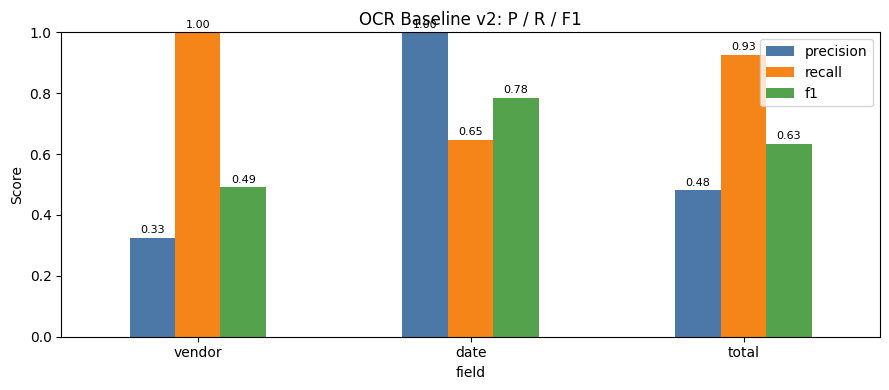


Top 10 worst documents:


,id,gt_vendor,pred_vendor,gt_date,pred_date,gt_total,pred_total,num_wrong_fields
11,X51005288570,secure parking corporation s/b,secure parking,2018-03-23,,1.00,,3
18,X51005361923,swc enterprise sdn bhd,swcenterprise sdn dad,2018-01-02,,4.20,50.20,3
10,X51005268408,99 speed mart s/b,"lot p,t, 2811 , jalax angsa,",2017-11-20,,169.80,206.60,3
31,X51005444040,bens independent grocer sdn. bhd,bens independent grocer sdn.,2018-03-09,,133.70,140.00,3
25,X51005442334,unihakka international sdn bhd,"12, jalan tampoi 7/4,kawasan perindustrian",2018-03-26,,8.20,58.20,3
22,X51005433548,pasar mini jin seng,bahdar earu fernas haya,2018-03-03,,33.80,93.80,3
21,X51005433543,unihakka international sdn bhd,"12, jjalan tampoi 7,4,kawasan perindustrian",2018-03-13,,8.20,38.20,3
34,X51005444046,star grocer sdn bhd,"desa pandan, off kampong pandan,",2018-03-25,,66.15,7.50,3
28,X51005442375,unihakka international sdn bhd,"12, jalan tampoj 7/4,kawasan perinduskian",2018-03-25,,8.50,38.50,3
29,X51005442382,unihakka international sdn bhd,"12 jalan tanpoi 7/4,kawasan perindustrian",2018-03-20,,6.60,6.80,3


In [10]:
# OCR Metrics
import matplotlib.pyplot as plt

pred_ocr = pd.read_csv(OUTPUT_ROOT / f'ocr_predictions_clean{RUN_SUFFIX}.csv')
gt_df = RUN_VAL[['id', 'gt_vendor', 'gt_date', 'gt_total']].copy()
ocr_metrics, ocr_errors = evaluate(gt_df, pred_ocr)

print('=== OCR Baseline Metrics ===')
display(ocr_metrics)

# Bar chart
field_m = ocr_metrics[ocr_metrics['field'].isin(['vendor','date','total'])].set_index('field')
ax = field_m[['precision','recall','f1']].plot(kind='bar', figsize=(9,4), ylim=(0,1), rot=0,
    color=['#4C78A8','#F58518','#54A24B'])
ax.set_title('OCR Baseline v2: P / R / F1')
ax.set_ylabel('Score')
for c in ax.containers: ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()

# Error analysis
print(f'\nTop 10 worst documents:')
display(ocr_errors[['id','gt_vendor','pred_vendor','gt_date','pred_date','gt_total','pred_total','num_wrong_fields']].head(10))

---
## 3. Donut Pretrained Inference

In [11]:
import re
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel

# Try SROIE-finetuned, then CORD
MODEL_CANDIDATES = [
    'philschmid/donut-base-sroie',
    'naver-clova-ix/donut-base-finetuned-cord-v2',
]

for name in MODEL_CANDIDATES:
    try:
        processor_pt = DonutProcessor.from_pretrained(name)
        model_pt = VisionEncoderDecoderModel.from_pretrained(name)
        MODEL_NAME_PT = name
        break
    except Exception as e:
        print(f'  {name}: {e}')
        continue
else:
    raise RuntimeError('Could not load any Donut model')

TASK_PROMPT_PT = '<s_sroie>' if 'sroie' in MODEL_NAME_PT.lower() else '<s_cord-v2>'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_pt = model_pt.to(device).eval()

print(f'Model: {MODEL_NAME_PT}')
print(f'Device: {device}')
print(f'Task prompt: {TASK_PROMPT_PT}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/809M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model: philschmid/donut-base-sroie
Device: cuda
Task prompt: <s_sroie>


In [12]:
# SROIE tag patterns
SROIE_TAG_RE = {
    'company': re.compile(r'<s_company>\s*(.*?)\s*</s_company>', re.DOTALL),
    'date':    re.compile(r'<s_date>\s*(.*?)\s*</s_date>', re.DOTALL),
    'total':   re.compile(r'<s_total>\s*(.*?)\s*</s_total>', re.DOTALL),
}
DATE_REGEX_LOCAL = re.compile(r'\b(\d{2}[./-]\d{2}[./-]\d{4}|\d{4}[./-]\d{2}[./-]\d{2})\b')
MONEY_2DP_RE = re.compile(r'\b(\d{1,6}\.\d{2})\b')


def parse_donut_output(raw_text, proc=processor_pt):
    """Multi-layer parser for Donut SROIE output."""
    vendor = date = total = ''

    # Layer 1: SROIE tags
    m = SROIE_TAG_RE['company'].search(raw_text)
    if m: vendor = m.group(1).strip()
    m = SROIE_TAG_RE['date'].search(raw_text)
    if m: date = normalize_date(m.group(1).strip())
    m = SROIE_TAG_RE['total'].search(raw_text)
    if m: total = normalize_total(m.group(1).strip())

    if vendor and date and total:
        return {'pred_vendor': vendor, 'pred_date': date, 'pred_total': total}

    # Layer 2: token2json
    try:
        payload = proc.token2json(raw_text)
        if isinstance(payload, dict):
            if not vendor:
                for k in ['company','vendor','store']:
                    if k in payload and payload[k]: vendor = str(payload[k]).strip(); break
            if not date:
                for k in ['date','invoice_date']:
                    if k in payload and payload[k]: date = normalize_date(str(payload[k])); break
            if not total:
                for k in ['total','total_price','amount']:
                    if k in payload and payload[k]: total = normalize_total(str(payload[k])); break
    except Exception:
        pass

    # Layer 3: regex fallback
    clean = re.sub(r'<[^>]+>', ' ', raw_text).strip()
    if not date:
        m = DATE_REGEX_LOCAL.search(clean)
        if m: date = normalize_date(m.group(1))
    if not total:
        for m in MONEY_2DP_RE.findall(clean):
            v = float(m)
            if 0.01 <= v <= 50000:
                total = normalize_total(m); break
    if not vendor:
        words = clean.split()
        if len(words) >= 2:
            snippet = ' '.join(words[:5])
            if sum(c.isalpha() for c in snippet) >= 3:
                vendor = snippet

    return {'pred_vendor': vendor, 'pred_date': date, 'pred_total': total}


def donut_predict_pt(image_path):
    """Donut pretrained inference on single image."""
    image = Image.open(image_path).convert('RGB')
    pixel_values = processor_pt(image, return_tensors='pt').pixel_values.to(device)
    decoder_input_ids = processor_pt.tokenizer(
        TASK_PROMPT_PT, add_special_tokens=False, return_tensors='pt'
    ).input_ids.to(device)

    with torch.no_grad():
        outputs = model_pt.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=model_pt.decoder.config.max_position_embeddings,
            pad_token_id=processor_pt.tokenizer.pad_token_id,
            eos_token_id=processor_pt.tokenizer.eos_token_id,
            num_beams=1, use_cache=True,
            bad_words_ids=[[processor_pt.tokenizer.unk_token_id]],
        )
    seq = processor_pt.batch_decode(outputs)[0]
    seq = seq.replace(processor_pt.tokenizer.eos_token, '').replace(processor_pt.tokenizer.pad_token, '')
    seq = re.sub(r'^<.*?>', '', seq, count=1).strip()
    parsed = parse_donut_output(seq)
    parsed['raw_text'] = seq
    return parsed


# Sanity test
test_pred = donut_predict_pt(manifest_val.iloc[0]['image_path'])
print('Sanity test:')
for k, v in test_pred.items():
    print(f'  {k}: {str(v)[:100]}')

Sanity test:
  pred_vendor: COPY SDN BHD NO 2
  pred_date: 
  pred_total: 
  raw_text: COPY SDN BHD</s_company><s_address> NO 2 & 4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR</s_


In [13]:
# Run Donut pretrained on all val docs
DONUT_PT_CSV = OUTPUT_ROOT / f'donut_pretrained_predictions{RUN_SUFFIX}.csv'

done_ids_dpt = set()
dpt_rows = []
dpt_latencies = []

if DONUT_PT_CSV.exists():
    existing = pd.read_csv(DONUT_PT_CSV)
    done_ids_dpt = set(existing['id'].tolist())
    dpt_rows = existing.to_dict('records')
    print(f'Resuming: {len(done_ids_dpt)} already done')

remaining_dpt = RUN_VAL[~RUN_VAL['id'].isin(done_ids_dpt)].reset_index(drop=True)
print(f'Remaining: {len(remaining_dpt)} docs')

for _, row in tqdm(remaining_dpt.iterrows(), total=len(remaining_dpt), desc='Donut-PT'):
    t0 = time.perf_counter()
    try:
        pred = donut_predict_pt(row['image_path'])
    except Exception as e:
        print(f'  ERROR {row["id"]}: {e}')
        pred = {'pred_vendor': '', 'pred_date': '', 'pred_total': '', 'raw_text': f'ERROR: {e}'}
    elapsed = (time.perf_counter() - t0) * 1000
    dpt_rows.append({
        'id': row['id'],
        'pred_vendor': pred['pred_vendor'],
        'pred_date': pred['pred_date'],
        'pred_total': pred['pred_total'],
        'latency_ms': elapsed,
    })
    dpt_latencies.append(elapsed)
    if len(dpt_rows) % 20 == 0:
        pd.DataFrame(dpt_rows).to_csv(DONUT_PT_CSV, index=False)

pred_dpt = pd.DataFrame(dpt_rows)
pred_dpt.to_csv(DONUT_PT_CSV, index=False)
print(f'Saved {len(pred_dpt)} predictions to {DONUT_PT_CSV.name}')
if dpt_latencies:
    print(f'Latency: mean={np.mean(dpt_latencies):.0f}ms, p50={np.percentile(dpt_latencies,50):.0f}ms')

Remaining: 80 docs


Donut-PT:   0%|          | 0/80 [00:00<?, ?it/s]

Saved 80 predictions to donut_pretrained_predictions_quick.csv
Latency: mean=2453ms, p50=449ms


In [14]:
# Donut pretrained metrics
pred_dpt = pd.read_csv(DONUT_PT_CSV)
dpt_metrics, dpt_errors = evaluate(gt_df, pred_dpt)
print('=== Donut Pretrained Metrics ===')
display(dpt_metrics)

# Diagnostic: show up to 5 raw outputs
print('\n--- Raw output samples ---')
for _, row in RUN_VAL.sample(min(5, len(RUN_VAL)), random_state=7).iterrows():
    pred = donut_predict_pt(row['image_path'])
    print(f"\n[{row['id']}]  GT: vendor={row['gt_vendor']!r}  date={row['gt_date']!r}  total={row['gt_total']}")
    print(f"  Pred: vendor={pred['pred_vendor']!r}  date={pred['pred_date']!r}  total={pred['pred_total']!r}")
    print(f"  Raw: {pred['raw_text'][:200]}")

=== Donut Pretrained Metrics ===


,precision,recall,f1,tp,fp,fn,support,field,exact_match
0,0.000000,0.000000,0.000000,0,79,1,80,vendor,0.000000
1,1.000000,0.025316,0.049383,2,0,77,79,date,0.025316
2,0.000000,0.000000,0.000000,0,5,75,80,total,0.000000
3,0.023256,0.012903,0.016598,2,84,153,239,micro,NaN



--- Raw output samples ---

[X51005675099]  GT: vendor='SUPER TERMINAL SDN BHD'  date='2018-01-20'  total=132.50
  Pred: vendor='SUPER TErmiNAI SDN BHD NO.'  date=''  total=''
  Raw: SUPER TErmiNAI SDN BHD</s_company><s_address> NO. 18 & 19, TAMAN CITY, JALAN KUCHING, 52100 KUALA LUMPUR</s_address>

[X51005447842]  GT: vendor='PASARAYA BORONG PINTAR SDN BHD'  date='2018-03-14'  total=0.90
  Pred: vendor='BORONG PINTAR SDN BHD NO'  date=''  total=''
  Raw: BORONG PINTAR SDN BHD</s_company><s_address> NO 19-G& 19-1& 19-2 JALAN TASK UTAMA 4, MEDAN NIAGA TASK DAMAI</s_address>

[X51005663310]  GT: vendor='LIM SENG THO HARDWARE TRADING'  date='2018-02-09'  total=8.40
  Pred: vendor='TRADING NO 7. SIMPANG OFF'  date=''  total=''
  Raw: TRADING</s_company><s_address> NO 7. SIMPANG OFF BATU VILLAGE, JALAN IPOH BATU 5, 51200 KUALA LUMPUR MALAYSIA</s_address>

[X51005361912]  GT: vendor='TEO HENG STATIONERY & BOOKS'  date='2018-01-29'  total=1.05
  Pred: vendor='BODYKAYA NO.83, JALAN BESAR, 450

---
## 4. Donut Fine-tuning on SROIE

In [15]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR

BASE_MODEL = 'naver-clova-ix/donut-base'

processor_ft = DonutProcessor.from_pretrained(BASE_MODEL)
model_ft = VisionEncoderDecoderModel.from_pretrained(BASE_MODEL)

# Add SROIE special tokens
SPECIAL_TOKENS = [
    '<s_sroie>', '</s_sroie>',
    '<s_company>', '</s_company>',
    '<s_date>', '</s_date>',
    '<s_total>', '</s_total>',
    '<s_address>', '</s_address>',
]
newly_added = processor_ft.tokenizer.add_special_tokens({'additional_special_tokens': SPECIAL_TOKENS})
model_ft.decoder.resize_token_embeddings(len(processor_ft.tokenizer))

TASK_PROMPT_FT = '<s_sroie>'
task_prompt_id = processor_ft.tokenizer.convert_tokens_to_ids(TASK_PROMPT_FT)
model_ft.config.decoder_start_token_id = task_prompt_id
model_ft.config.pad_token_id = processor_ft.tokenizer.pad_token_id

model_ft = model_ft.to(device)
print(f'Base model loaded. Added {newly_added} tokens. Vocab: {len(processor_ft.tokenizer)}')

preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/71.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/809M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Base model loaded. Added 10 tokens. Vocab: 57535


In [16]:
class SROIEDonutDataset(Dataset):
    def __init__(self, manifest_df, processor, max_length=256):
        self.manifest = manifest_df.reset_index(drop=True)
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        pixel_values = self.processor(image, return_tensors='pt').pixel_values.squeeze(0)

        vendor = str(row.get('gt_vendor', '') or '')
        date   = str(row.get('gt_date', '') or '')
        total  = str(row.get('gt_total', '') or '')

        target = (
            f'<s_sroie>'
            f'<s_company>{vendor}</s_company>'
            f'<s_date>{date}</s_date>'
            f'<s_total>{total}</s_total>'
            f'</s_sroie>'
        )
        encoding = self.processor.tokenizer(
            target, add_special_tokens=False,
            max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt',
        )
        labels = encoding.input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {'pixel_values': pixel_values, 'labels': labels}


train_ds = SROIEDonutDataset(RUN_TRAIN, processor_ft)
val_ds   = SROIEDonutDataset(RUN_VAL, processor_ft)
print(f'Train: {len(train_ds)}, Val: {len(val_ds)}')

sample = train_ds[0]
print(f'pixel_values: {sample["pixel_values"].shape}')
print(f'labels (non-pad): {(sample["labels"] != -100).sum().item()} tokens')

Train: 240, Val: 80
pixel_values: torch.Size([3, 2560, 1920])
labels (non-pad): 29 tokens


GPU free after cleanup: 6.7 GiB
Training image size: 1280x960 (reduced from 2560x1920)
pixel_values shape: torch.Size([3, 1280, 960])
Run profile: quick | epochs=2 | batch=1 | accum=2
Steps/epoch: 240, Total: 480, Warmup: 48
Using fp16 mixed precision (no gradient checkpointing)


Epoch 1/2:   0%|          | 0/240 [00:00<?, ?it/s]

/tmp/ipython-input-3874493909.py:71: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  Epoch 1: avg_loss=4.9423


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best checkpoint saved (loss=4.9423)


Epoch 2/2:   0%|          | 0/240 [00:00<?, ?it/s]

  Epoch 2: avg_loss=0.7961


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best checkpoint saved (loss=0.7961)

Training complete. Best loss: 0.7961


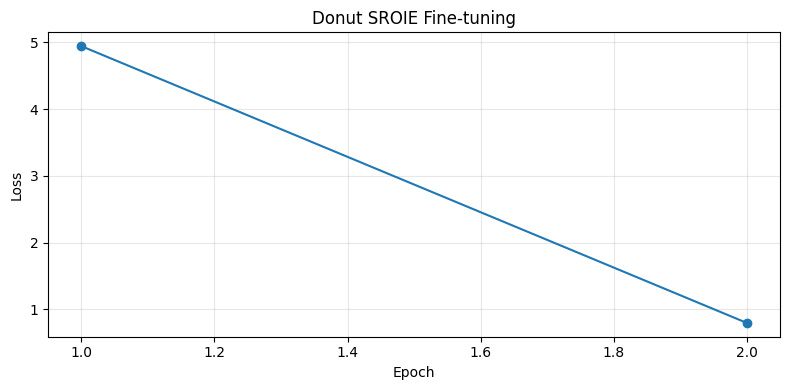

In [20]:
# Free ALL unnecessary VRAM before fine-tuning
import gc

for _var in ['model_pt', 'processor_pt', 'reader']:
    if _var in globals():
        del globals()[_var]

gc.collect()
torch.cuda.empty_cache()
print(f'GPU free after cleanup: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GiB')

# Reduce image resolution for training to fit T4 16GB
IMG_H, IMG_W = 1280, 960
processor_ft.image_processor.size = {"height": IMG_H, "width": IMG_W}
print(f'Training image size: {IMG_H}x{IMG_W} (reduced from 2560x1920)')

# Rebuild datasets with new resolution
train_ds = SROIEDonutDataset(RUN_TRAIN, processor_ft)
val_ds   = SROIEDonutDataset(RUN_VAL, processor_ft)
sample = train_ds[0]
print(f'pixel_values shape: {sample["pixel_values"].shape}')

# Training config
EPOCHS = 2 if RUN_PROFILE == 'quick' else 5
BATCH_SIZE = 1
ACCUM_STEPS = 2           # effective batch = 2
LR = 5e-5
LOG_EVERY = 50

print(f'Run profile: {RUN_PROFILE} | epochs={EPOCHS} | batch={BATCH_SIZE} | accum={ACCUM_STEPS}')

CHECKPOINT_DIR = PROJECT_ROOT / 'v2' / 'checkpoints' / f'donut-sroie-finetuned{RUN_SUFFIX}'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

optimizer = AdamW(model_ft.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps)

scaler = torch.amp.GradScaler('cuda')  # fp16 mixed precision
print(f'Steps/epoch: {len(train_loader)}, Total: {total_steps}, Warmup: {warmup_steps}')
print('Using fp16 mixed precision (no gradient checkpointing)')

best_loss = float('inf')
history = []

for epoch in range(1, EPOCHS + 1):
    model_ft.train()
    epoch_loss = 0.0
    n_batches = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')
    optimizer.zero_grad()
    for step, batch in enumerate(pbar, 1):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        with torch.amp.autocast('cuda'):
            outputs = model_ft(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / ACCUM_STEPS

        scaler.scale(loss).backward()

        if step % ACCUM_STEPS == 0 or step == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_ft.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        epoch_loss += outputs.loss.item()
        n_batches += 1

        if step % LOG_EVERY == 0:
            pbar.set_postfix(loss=f'{epoch_loss/n_batches:.4f}', lr=f'{scheduler.get_last_lr()[0]:.2e}')

    avg_loss = epoch_loss / max(n_batches, 1)
    history.append({'epoch': epoch, 'train_loss': avg_loss})
    print(f'  Epoch {epoch}: avg_loss={avg_loss:.4f}')

    if avg_loss < best_loss:
        best_loss = avg_loss
        model_ft.save_pretrained(CHECKPOINT_DIR)
        processor_ft.save_pretrained(CHECKPOINT_DIR)
        print(f'  -> Best checkpoint saved (loss={best_loss:.4f})')

print(f'\nTraining complete. Best loss: {best_loss:.4f}')

# Plot training curve
hist_df = pd.DataFrame(history)
plt.figure(figsize=(8, 4))
plt.plot(hist_df['epoch'], hist_df['train_loss'], 'o-')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Donut SROIE Fine-tuning'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [21]:
# Load best checkpoint and run full validation
ft_processor = DonutProcessor.from_pretrained(str(CHECKPOINT_DIR))
ft_model = VisionEncoderDecoderModel.from_pretrained(str(CHECKPOINT_DIR)).to(device).eval()

def donut_predict_ft(image_path):
    image = Image.open(image_path).convert('RGB')
    pixel_values = ft_processor(image, return_tensors='pt').pixel_values.to(device)
    decoder_input_ids = ft_processor.tokenizer(
        '<s_sroie>', add_special_tokens=False, return_tensors='pt'
    ).input_ids.to(device)

    with torch.no_grad():
        outputs = ft_model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=ft_model.decoder.config.max_position_embeddings,
            pad_token_id=ft_processor.tokenizer.pad_token_id,
            eos_token_id=ft_processor.tokenizer.eos_token_id,
            num_beams=1, use_cache=True,
            bad_words_ids=[[ft_processor.tokenizer.unk_token_id]],
        )
    seq = ft_processor.batch_decode(outputs)[0]
    seq = seq.replace(ft_processor.tokenizer.eos_token, '').replace(ft_processor.tokenizer.pad_token, '')

    vendor = date = total = ''
    m = re.search(r'<s_company>(.*?)</s_company>', seq, re.DOTALL)
    if m: vendor = m.group(1).strip()
    m = re.search(r'<s_date>(.*?)</s_date>', seq, re.DOTALL)
    if m: date = normalize_date(m.group(1).strip())
    m = re.search(r'<s_total>(.*?)</s_total>', seq, re.DOTALL)
    if m: total = normalize_total(m.group(1).strip())
    return {'pred_vendor': vendor, 'pred_date': date, 'pred_total': total}


# Full validation with checkpointing
DONUT_FT_CSV = OUTPUT_ROOT / f'donut_predictions_clean{RUN_SUFFIX}.csv'
ft_ckpt = OUTPUT_ROOT / f'donut_ft_checkpoint{RUN_SUFFIX}.csv'

done_ft = set()
ft_rows = []
ft_lats = []

if ft_ckpt.exists():
    existing = pd.read_csv(ft_ckpt)
    done_ft = set(existing['id'].tolist())
    ft_rows = existing.to_dict('records')
    print(f'Resuming FT val: {len(done_ft)} done')

remaining_ft = RUN_VAL[~RUN_VAL['id'].isin(done_ft)].reset_index(drop=True)
print(f'Remaining: {len(remaining_ft)} docs')

for _, row in tqdm(remaining_ft.iterrows(), total=len(remaining_ft), desc='Donut-FT val'):
    t0 = time.perf_counter()
    try:
        pred = donut_predict_ft(row['image_path'])
    except Exception as e:
        pred = {'pred_vendor': '', 'pred_date': '', 'pred_total': ''}
    elapsed = (time.perf_counter() - t0) * 1000
    ft_rows.append({'id': row['id'], **pred, 'latency_ms': elapsed})
    ft_lats.append(elapsed)
    if len(ft_rows) % 20 == 0:
        pd.DataFrame(ft_rows).to_csv(ft_ckpt, index=False)

pred_ft = pd.DataFrame(ft_rows)
pred_ft.to_csv(DONUT_FT_CSV, index=False)
if ft_ckpt.exists(): ft_ckpt.unlink()

print(f'\nSaved {len(pred_ft)} FT predictions')
ft_metrics, _ = evaluate(gt_df, pred_ft)
print('=== Donut Fine-tuned Metrics ===')
display(ft_metrics)
if ft_lats:
    print(f'Latency: mean={np.mean(ft_lats):.0f}ms')

Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Remaining: 80 docs


Donut-FT val:   0%|          | 0/80 [00:00<?, ?it/s]


Saved 80 FT predictions
=== Donut Fine-tuned Metrics ===


,precision,recall,f1,tp,fp,fn,support,field,exact_match
0,0.700000,1.000000,0.823529,56,24,0,80,vendor,0.700000
1,0.467532,0.947368,0.626087,36,41,2,79,date,0.455696
2,0.637500,1.000000,0.778626,51,29,0,80,total,0.637500
3,0.603376,0.986207,0.748691,143,94,2,239,micro,NaN


Latency: mean=8866ms


---
## 5. Robustness Evaluation

Corrupting:   0%|          | 0/80 [00:00<?, ?it/s]

Generated 80 corrupted images


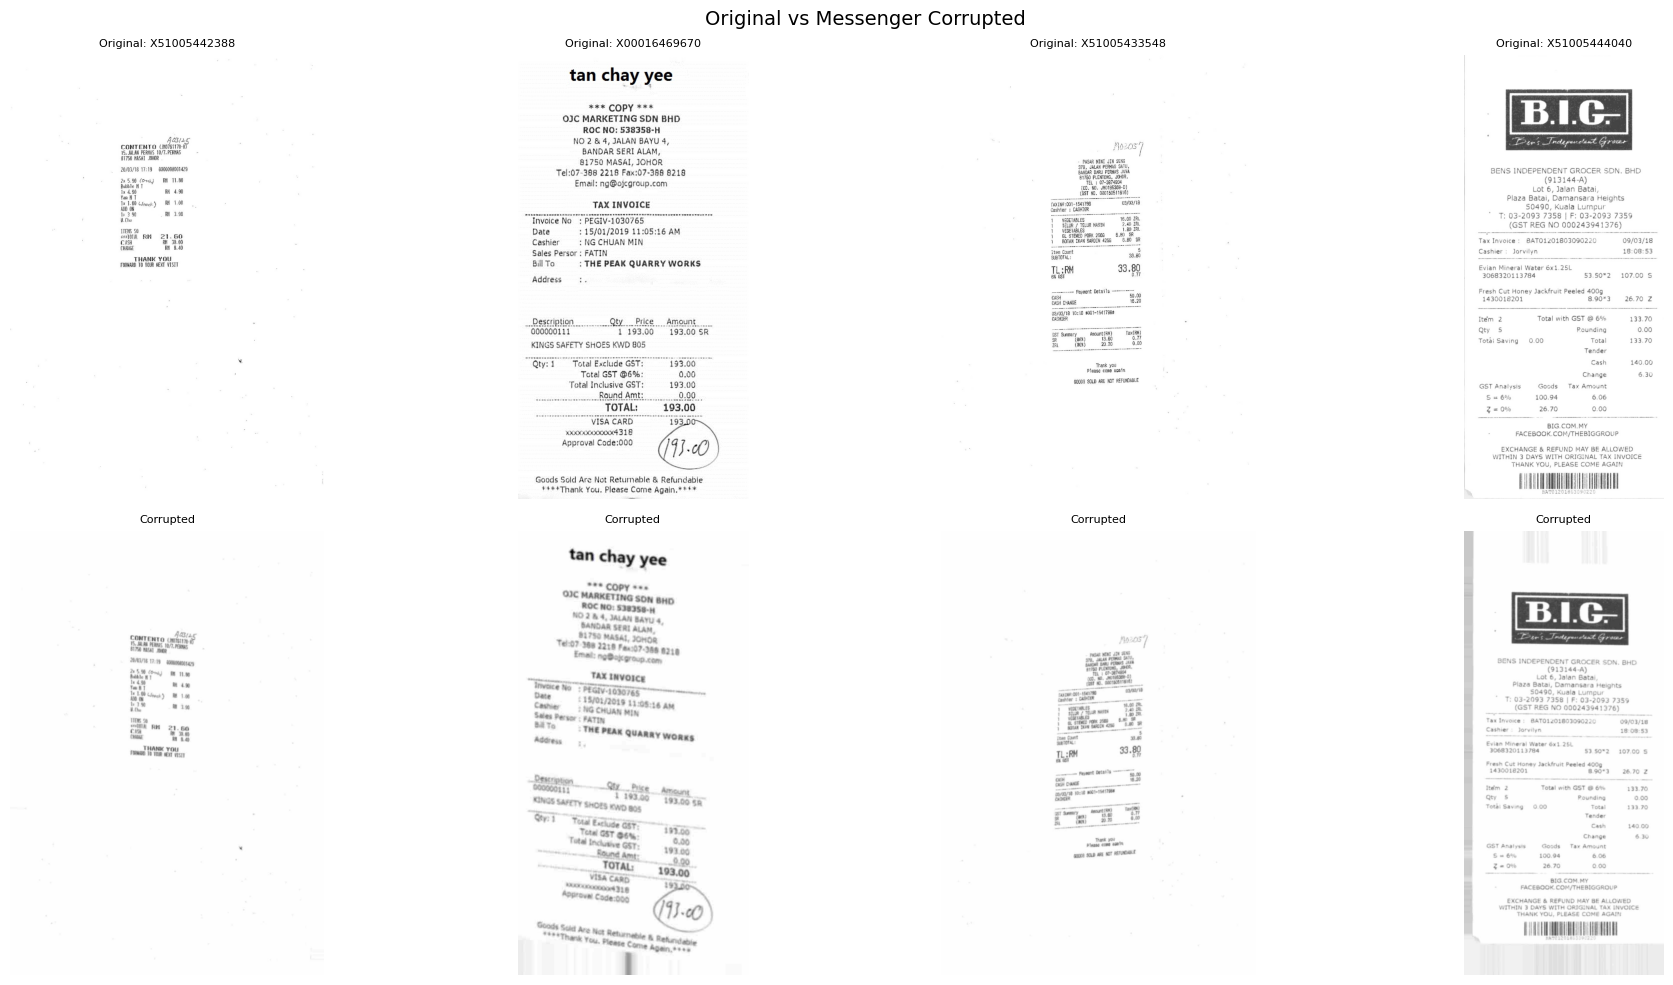

In [22]:
import cv2
import random
random.seed(42)
np.random.seed(42)

CORRUPT_DIR = OUTPUT_ROOT / f'robustness{RUN_SUFFIX}'
CORRUPT_DIR.mkdir(parents=True, exist_ok=True)

corrupt_paths = {}
for _, row in tqdm(RUN_VAL.iterrows(), total=len(RUN_VAL), desc='Corrupting'):
    img_bgr = cv2.imread(str(row['image_path']))
    if img_bgr is None:
        continue
    corrupted = messenger_corrupt(img_bgr, jpeg_quality=22, blur_kernel=5, perspective=0.08, downscale=0.6)
    out_path = CORRUPT_DIR / f'{row["id"]}_messenger.jpg'
    cv2.imwrite(str(out_path), corrupted)
    corrupt_paths[row['id']] = str(out_path)

print(f'Generated {len(corrupt_paths)} corrupted images')

# Show examples
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
sample_ids = RUN_VAL.sample(min(4, len(RUN_VAL)), random_state=42)['id'].tolist()
for i, doc_id in enumerate(sample_ids):
    row = RUN_VAL[RUN_VAL['id'] == doc_id].iloc[0]
    axes[0, i].imshow(Image.open(row['image_path']))
    axes[0, i].set_title(f'Original: {doc_id}', fontsize=8); axes[0, i].axis('off')
    axes[1, i].imshow(Image.open(corrupt_paths[doc_id]))
    axes[1, i].set_title('Corrupted', fontsize=8); axes[1, i].axis('off')
plt.suptitle('Original vs Messenger Corrupted', fontsize=14)
plt.tight_layout(); plt.show()

In [23]:
# OCR on corrupted images
import easyocr

OCR_CORR_CSV = OUTPUT_ROOT / f'ocr_predictions_corrupted{RUN_SUFFIX}.csv'
ocr_corr_rows = []

if OCR_CORR_CSV.exists():
    print(f'OCR corrupted predictions already exist. Skipping.')
    ocr_corr_rows = pd.read_csv(OCR_CORR_CSV).to_dict('records')
else:
    # Re-initialize EasyOCR reader (it was freed for fine-tuning)
    if 'reader' not in dir() or reader is None:
        reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
        print('EasyOCR reader re-initialized')

    for _, row in tqdm(RUN_VAL.iterrows(), total=len(RUN_VAL), desc='OCR corrupted'):
        if row['id'] not in corrupt_paths:
            continue
        try:
            ocr_result = reader.readtext(corrupt_paths[row['id']], detail=1, paragraph=False)
            lines = [item[1] for item in ocr_result]
        except Exception:
            lines = []
        fields = extract_fields_from_lines(lines)
        ocr_corr_rows.append({'id': row['id'], **fields})

    pd.DataFrame(ocr_corr_rows).to_csv(OCR_CORR_CSV, index=False)

print(f'OCR corrupted: {len(ocr_corr_rows)} predictions')

EasyOCR reader re-initialized


OCR corrupted:   0%|          | 0/80 [00:00<?, ?it/s]

OCR corrupted: 80 predictions


In [24]:
# Donut (fine-tuned) on corrupted images
DONUT_CORR_CSV = OUTPUT_ROOT / f'donut_predictions_corrupted{RUN_SUFFIX}.csv'
donut_corr_rows = []

if DONUT_CORR_CSV.exists():
    print(f'Donut corrupted predictions already exist. Skipping.')
    donut_corr_rows = pd.read_csv(DONUT_CORR_CSV).to_dict('records')
else:
    for _, row in tqdm(RUN_VAL.iterrows(), total=len(RUN_VAL), desc='Donut-FT corrupted'):
        if row['id'] not in corrupt_paths:
            continue
        try:
            pred = donut_predict_ft(corrupt_paths[row['id']])
        except Exception:
            pred = {'pred_vendor': '', 'pred_date': '', 'pred_total': ''}
        donut_corr_rows.append({'id': row['id'], **pred})

    pd.DataFrame(donut_corr_rows).to_csv(DONUT_CORR_CSV, index=False)

print(f'Donut corrupted: {len(donut_corr_rows)} predictions')

Donut-FT corrupted:   0%|          | 0/80 [00:00<?, ?it/s]

Donut corrupted: 80 predictions


---
## 6. Final Summary & Visualizations

In [25]:
import warnings
import matplotlib as mpl
mpl.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

# Load all prediction CSVs
PRED_FILES = {
    ('OCR', 'clean'):           f'ocr_predictions_clean{RUN_SUFFIX}.csv',
    ('OCR', 'corrupted'):       f'ocr_predictions_corrupted{RUN_SUFFIX}.csv',
    ('Donut-PT', 'clean'):      f'donut_pretrained_predictions{RUN_SUFFIX}.csv',
    ('Donut-FT', 'clean'):      f'donut_predictions_clean{RUN_SUFFIX}.csv',
    ('Donut-FT', 'corrupted'):  f'donut_predictions_corrupted{RUN_SUFFIX}.csv',
}

predictions = {}
for (pipeline, condition), fname in PRED_FILES.items():
    fpath = OUTPUT_ROOT / fname
    if fpath.exists():
        predictions[(pipeline, condition)] = pd.read_csv(fpath)
        print(f'  Loaded {fname:45s} ({len(predictions[(pipeline,condition)])} rows)')
    else:
        print(f'  MISSING: {fname}')

print(f'\nAvailable: {list(predictions.keys())}')

  Loaded ocr_predictions_clean_quick.csv               (80 rows)
  Loaded ocr_predictions_corrupted_quick.csv           (80 rows)
  Loaded donut_pretrained_predictions_quick.csv        (80 rows)
  Loaded donut_predictions_clean_quick.csv             (80 rows)
  Loaded donut_predictions_corrupted_quick.csv         (80 rows)

Available: [('OCR', 'clean'), ('OCR', 'corrupted'), ('Donut-PT', 'clean'), ('Donut-FT', 'clean'), ('Donut-FT', 'corrupted')]


In [26]:
# Compute metrics for all available pipelines
gt_cols = ['id', 'gt_vendor', 'gt_date', 'gt_total']
summary_rows = []

for (pipeline, condition), pred_df in predictions.items():
    metrics_df, _ = evaluate(RUN_VAL[gt_cols], pred_df)
    row = {'Pipeline': pipeline, 'Condition': condition}
    for _, m in metrics_df.iterrows():
        field = m['field']
        if field == 'micro':
            row['Micro_F1'] = round(m['f1'], 4)
        else:
            fname = field.capitalize()
            row[f'{fname}_P'] = round(m['precision'], 4)
            row[f'{fname}_R'] = round(m['recall'], 4)
            row[f'{fname}_F1'] = round(m['f1'], 4)
            row[f'{fname}_Exact'] = round(m['exact_match'], 4)
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
col_order = ['Pipeline','Condition',
    'Vendor_P','Vendor_R','Vendor_F1','Vendor_Exact',
    'Date_P','Date_R','Date_F1','Date_Exact',
    'Total_P','Total_R','Total_F1','Total_Exact',
    'Micro_F1']
col_order = [c for c in col_order if c in summary.columns]
summary = summary[col_order]

print('=== MAIN COMPARISON TABLE ===')
display(summary)

# Save
summary_path = OUTPUT_ROOT / f'results_summary{RUN_SUFFIX}.csv'
summary.to_csv(summary_path, index=False)
print(f'\nSaved to {summary_path}')

=== MAIN COMPARISON TABLE ===


,Pipeline,Condition,Vendor_P,Vendor_R,Vendor_F1,Vendor_Exact,Date_P,Date_R,Date_F1,Date_Exact,Total_P,Total_R,Total_F1,Total_Exact,Micro_F1
0,OCR,clean,0.3250,1.0000,0.4906,0.325,1.0000,0.6456,0.7846,0.6456,0.4805,0.925,0.6325,0.4625,0.6459
1,OCR,corrupted,0.2564,0.9091,0.4000,0.250,0.9688,0.3974,0.5636,0.3924,0.3710,0.561,0.4466,0.2875,0.4728
2,Donut-PT,clean,0.0000,0.0000,0.0000,0.000,1.0000,0.0253,0.0494,0.0253,0.0000,0.000,0.0000,0.0000,0.0166
3,Donut-FT,clean,0.7000,1.0000,0.8235,0.700,0.4675,0.9474,0.6261,0.4557,0.6375,1.000,0.7786,0.6375,0.7487
4,Donut-FT,corrupted,0.5250,1.0000,0.6885,0.525,0.3867,0.8788,0.5370,0.3671,0.4750,1.000,0.6441,0.4750,0.6264



Saved to /content/invoice_docai/v2/outputs/results_summary_quick.csv


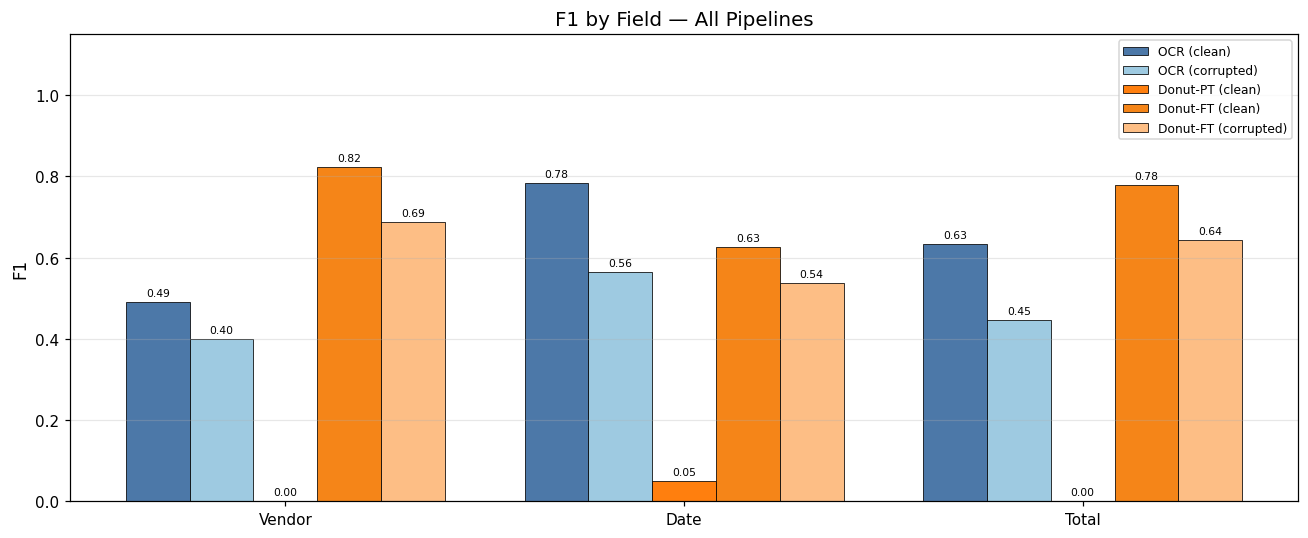

In [27]:
# Visualization 1: Grouped bar chart of F1 by field
FIELDS = ['Vendor', 'Date', 'Total']
f1_cols = [f'{f}_F1' for f in FIELDS]
labels = summary.apply(lambda r: f"{r['Pipeline']} ({r['Condition']})", axis=1).tolist()

x = np.arange(len(FIELDS))
n_bars = len(summary)
width = 0.8 / max(n_bars, 1)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4c78a8', '#9ecae1', '#ff7f0e', '#f58518', '#fdbe85']
for i, (idx, row) in enumerate(summary.iterrows()):
    vals = [row.get(c, 0) for c in f1_cols]
    offset = (i - n_bars / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=labels[i],
                  color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(FIELDS)
ax.set_ylabel('F1'); ax.set_title('F1 by Field — All Pipelines')
ax.set_ylim(0, 1.15); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / f'fig_f1_by_field{RUN_SUFFIX}.png', dpi=150, bbox_inches='tight')
plt.show()

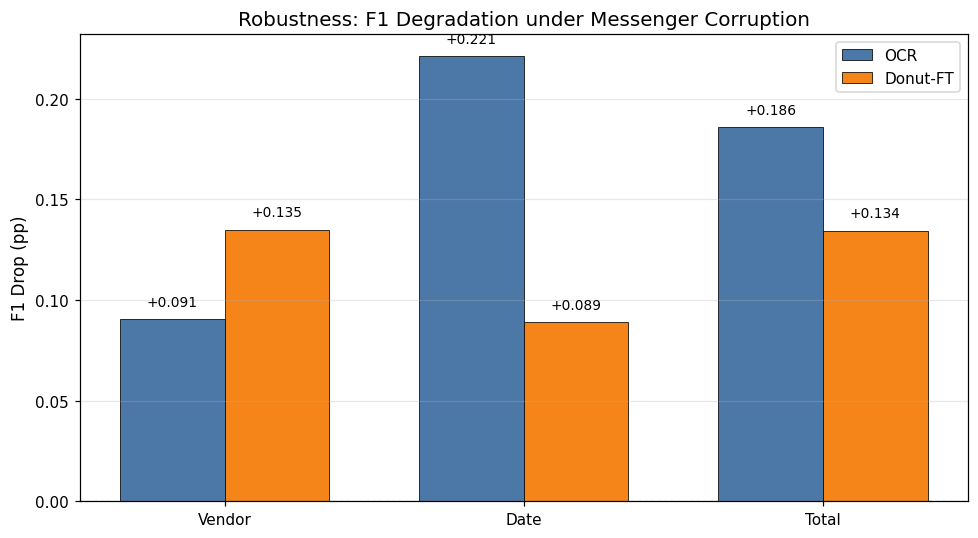

In [28]:
# Visualization 2: Degradation chart
degrad_rows = []
for pipeline in summary['Pipeline'].unique():
    conds = summary.loc[summary['Pipeline']==pipeline, 'Condition'].tolist()
    if 'clean' in conds and 'corrupted' in conds:
        clean_r = summary[(summary['Pipeline']==pipeline)&(summary['Condition']=='clean')].iloc[0]
        corr_r  = summary[(summary['Pipeline']==pipeline)&(summary['Condition']=='corrupted')].iloc[0]
        for field in FIELDS:
            f1c = clean_r.get(f'{field}_F1', 0)
            f1d = corr_r.get(f'{field}_F1', 0)
            degrad_rows.append({'Pipeline': pipeline, 'Field': field,
                                'F1_Clean': f1c, 'F1_Corrupted': f1d, 'Degradation': f1c - f1d})

if degrad_rows:
    degrad_df = pd.DataFrame(degrad_rows)
    degrad_df.to_csv(OUTPUT_ROOT / f'robustness_results{RUN_SUFFIX}.csv', index=False)

    x = np.arange(len(FIELDS))
    pipes = degrad_df['Pipeline'].unique()
    width = 0.35
    pipe_colors = {'OCR': '#4c78a8', 'Donut-FT': '#f58518'}

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, pipe in enumerate(pipes):
        vals = degrad_df[degrad_df['Pipeline']==pipe]['Degradation'].values
        offset = (i - len(pipes)/2 + 0.5) * width
        bars = ax.bar(x+offset, vals, width, label=pipe,
                      color=pipe_colors.get(pipe, f'C{i}'), edgecolor='black', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:+.3f}',
                    ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x); ax.set_xticklabels(FIELDS)
    ax.set_ylabel('F1 Drop (pp)'); ax.set_title('Robustness: F1 Degradation under Messenger Corruption')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / f'fig_degradation{RUN_SUFFIX}.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No degradation data (need clean+corrupted for same pipeline)')

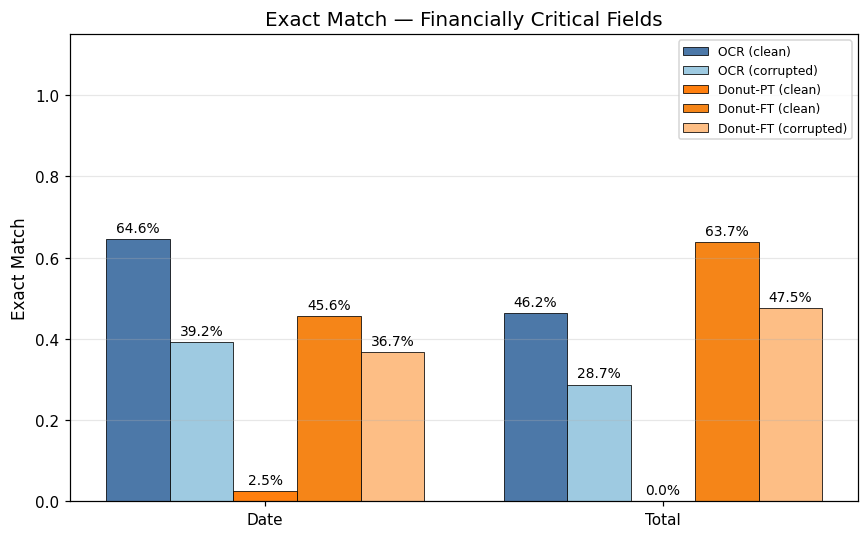

In [29]:
# Visualization 3: Exact match for Date & Total
CRITICAL = ['Date', 'Total']
exact_cols = [f'{f}_Exact' for f in CRITICAL]

x = np.arange(len(CRITICAL))
n_bars = len(summary)
width = 0.8 / max(n_bars, 1)

fig, ax = plt.subplots(figsize=(8, 5))
for i, (idx, row) in enumerate(summary.iterrows()):
    vals = [row.get(c, 0) for c in exact_cols]
    offset = (i - n_bars/2 + 0.5) * width
    bars = ax.bar(x+offset, vals, width, label=labels[i],
                  color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.1%}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(CRITICAL)
ax.set_ylabel('Exact Match'); ax.set_title('Exact Match — Financially Critical Fields')
ax.set_ylim(0, 1.15); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / f'fig_exact_match{RUN_SUFFIX}.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Final summary text
import zipfile
from pathlib import Path

print('=' * 70)
print('MODEL COMPARISON SUMMARY')
print('=' * 70)

clean_rows = summary[summary['Condition'] == 'clean']
if len(clean_rows) >= 2:
    print('\n--- Best pipeline per field (clean) ---')
    for field in FIELDS:
        col = f'{field}_F1'
        if col in clean_rows.columns:
            best_idx = clean_rows[col].idxmax()
            best = clean_rows.loc[best_idx]
            print(f'  {field:>8s}: {best["Pipeline"]} (F1={best[col]:.4f})')

if degrad_rows:
    print('\n--- Robustness (avg F1 degradation) ---')
    for pipe in degrad_df['Pipeline'].unique():
        avg = degrad_df[degrad_df['Pipeline']==pipe]['Degradation'].mean()
        print(f'  {pipe:>10s}: {avg:+.4f}')

print('\n--- Full results table ---')
display(summary)
print('\n' + '=' * 70)

# Persist results: prefer Google Drive, fallback to ZIP in /content
copied = 0
saved_files = [
    f for f in sorted(OUTPUT_ROOT.glob('*'))
    if f.is_file() and f.suffix in ['.csv', '.png']
]

if DRIVE_MOUNTED:
    if 'V2_DRIVE' in globals() and V2_DRIVE is not None:
        drive_output = V2_DRIVE / 'outputs'
    elif 'DRIVE_OUTPUT_DIR' in globals() and DRIVE_OUTPUT_DIR is not None:
        drive_output = DRIVE_OUTPUT_DIR
    else:
        drive_output = Path('/content/drive/MyDrive/invoice_docai/v2/outputs')

    drive_output.mkdir(parents=True, exist_ok=True)
    for f in saved_files:
        shutil.copy2(f, drive_output / f.name)
        copied += 1
    print(f'\nCopied {copied} result files to Google Drive: {drive_output}')
else:
    zip_path = Path('/content') / f'invoice_docai_outputs{RUN_SUFFIX}.zip'
    with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
        for f in saved_files:
            zf.write(f, arcname=f.name)
    print(f'\nDrive is not mounted. Created ZIP with outputs: {zip_path}')
    try:
        from google.colab import files
        files.download(str(zip_path))
    except Exception:
        print('Auto-download is unavailable in this client. Download the ZIP manually from /content.')

print('\nAll local outputs:')
for f in sorted(OUTPUT_ROOT.glob('*')):
    if f.is_file():
        print(f'  {f.name} ({f.stat().st_size:,} bytes)')
print('\nDONE!')

MODEL COMPARISON SUMMARY

--- Best pipeline per field (clean) ---
    Vendor: Donut-FT (F1=0.8235)
      Date: OCR (F1=0.7846)
     Total: Donut-FT (F1=0.7786)

--- Robustness (avg F1 degradation) ---
         OCR: +0.1658
    Donut-FT: +0.1195

--- Full results table ---


,Pipeline,Condition,Vendor_P,Vendor_R,Vendor_F1,Vendor_Exact,Date_P,Date_R,Date_F1,Date_Exact,Total_P,Total_R,Total_F1,Total_Exact,Micro_F1
0,OCR,clean,0.3250,1.0000,0.4906,0.325,1.0000,0.6456,0.7846,0.6456,0.4805,0.925,0.6325,0.4625,0.6459
1,OCR,corrupted,0.2564,0.9091,0.4000,0.250,0.9688,0.3974,0.5636,0.3924,0.3710,0.561,0.4466,0.2875,0.4728
2,Donut-PT,clean,0.0000,0.0000,0.0000,0.000,1.0000,0.0253,0.0494,0.0253,0.0000,0.000,0.0000,0.0000,0.0166
3,Donut-FT,clean,0.7000,1.0000,0.8235,0.700,0.4675,0.9474,0.6261,0.4557,0.6375,1.000,0.7786,0.6375,0.7487
4,Donut-FT,corrupted,0.5250,1.0000,0.6885,0.525,0.3867,0.8788,0.5370,0.3671,0.4750,1.000,0.6441,0.4750,0.6264




Copied 10 result files to Google Drive: /content/drive/MyDrive/invoice_docai/v2/outputs

All local outputs:
  donut_predictions_clean_quick.csv (5,769 bytes)
  donut_predictions_corrupted_quick.csv (4,347 bytes)
  donut_pretrained_predictions_quick.csv (22,226 bytes)
  fig_degradation_quick.png (44,984 bytes)
  fig_exact_match_quick.png (55,389 bytes)
  fig_f1_by_field_quick.png (50,587 bytes)
  ocr_predictions_clean_quick.csv (5,738 bytes)
  ocr_predictions_corrupted_quick.csv (3,665 bytes)
  results_summary_quick.csv (601 bytes)
  robustness_results_quick.csv (310 bytes)

DONE!


In [34]:
# Export outputs for VS Code + Colab kernel (no web-UI dependency)
from pathlib import Path
import zipfile

outputs_dir = Path('/content/invoice_docai/v2/outputs')
zip_name = f'invoice_docai_outputs{RUN_SUFFIX}.zip'
zip_path = Path('/content') / zip_name

files_to_pack = [f for f in outputs_dir.glob('*') if f.is_file() and f.suffix.lower() in {'.csv', '.png'}]
print(f'Found {len(files_to_pack)} files in {outputs_dir}')

if not files_to_pack:
    print('No files found in /content outputs. If kernel restarted, run only summary cells first.')
else:
    with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
        for f in files_to_pack:
            zf.write(f, arcname=f.name)
    print(f'ZIP created: {zip_path} ({zip_path.stat().st_size:,} bytes)')

    # Preferred in VS Code: persist ZIP to Google Drive
    if 'DRIVE_MOUNTED' in globals() and DRIVE_MOUNTED:
        drive_zip_dir = Path('/content/drive/MyDrive/invoice_docai/v2/outputs')
        drive_zip_dir.mkdir(parents=True, exist_ok=True)
        drive_zip_path = drive_zip_dir / zip_name
        import shutil
        shutil.copy2(zip_path, drive_zip_path)
        print(f'ZIP copied to Google Drive: {drive_zip_path}')
        print('Open Google Drive (desktop/web) and copy this ZIP to your local project folder.')
    else:
        print('Drive not mounted. Mount Drive in cell 3, then rerun this cell.')

    # Optional web download (works mainly in Colab browser UI)
    try:
        from google.colab import files
        files.download(str(zip_path))
        print('Web download attempted (may be unavailable in VS Code).')
    except Exception as e:
        print(f'Web download unavailable in VS Code environment: {e}')

Found 10 files in /content/invoice_docai/v2/outputs
ZIP created: /content/invoice_docai_outputs_quick.zip (131,311 bytes)
ZIP copied to Google Drive: /content/drive/MyDrive/invoice_docai/v2/outputs/invoice_docai_outputs_quick.zip
Open Google Drive (desktop/web) and copy this ZIP to your local project folder.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Web download attempted (may be unavailable in VS Code).
